In [1]:
import warnings
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message=".*FigureCanvasAgg is non-interactive.*"
)
import os
os.environ["NIXTLA_ID_AS_COL"] = "true"
import numpy as np
np.set_printoptions(suppress=True)
np.random.seed(1)
import random
random.seed(1)
import pandas as pd
pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)
from utilsforecast.plotting import plot_series as plot_series_utils
import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
})
import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])
from fpppy.utils import plot_series

In [2]:
import calendar

from coreforecast.scalers import boxcox, boxcox_lambda
from statsmodels.tsa.seasonal import STL, seasonal_decompose

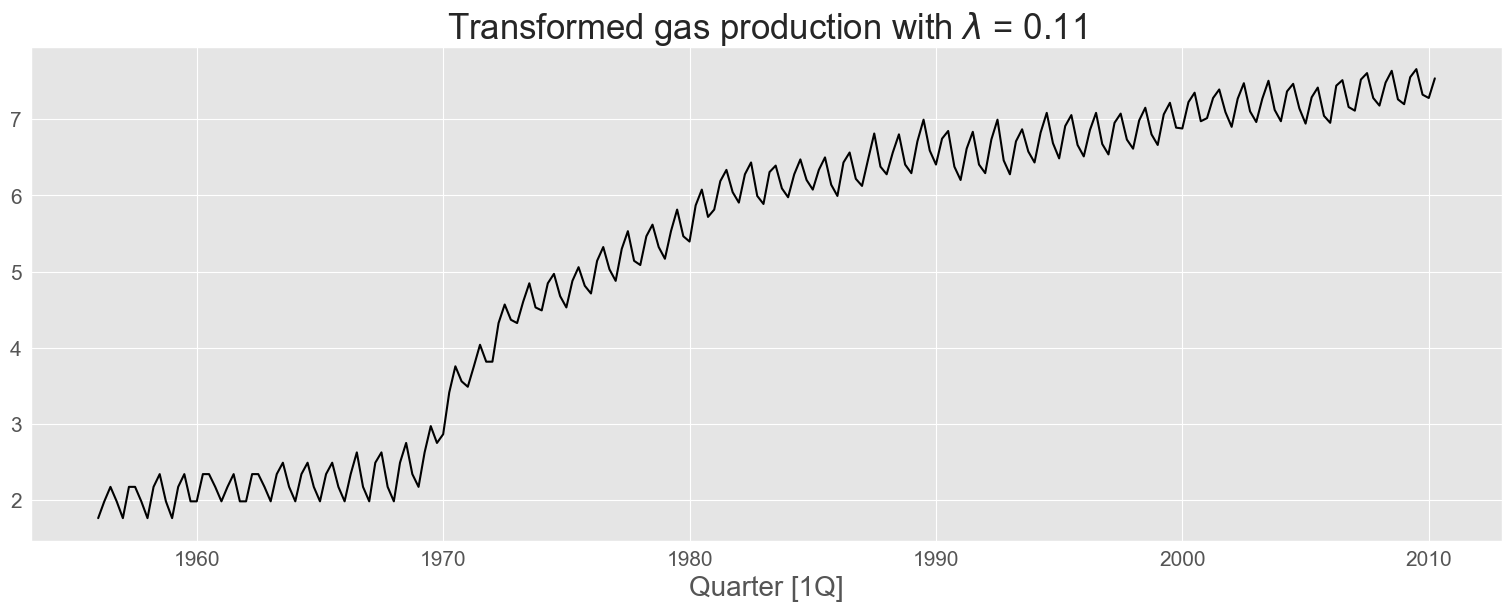

In [3]:
aus_production = pd.read_csv("aus_production.csv",
    parse_dates=["ds"])
aus_gas = (
    aus_production[["ds", "Gas"]]
    .rename(columns={"Gas": "y"})
    .assign(unique_id="Gas")
)

y = aus_gas["y"].to_numpy()
optim_lambda = boxcox_lambda(y, method="guerrero", season_length=4)
df = aus_gas.assign(y_transformed=boxcox(y, optim_lambda))

title = rf"Transformed gas production with $\lambda$ = {optim_lambda:.2f}"
plot_series(df, target_col="y_transformed",
    xlabel="Quarter [1Q]", ylabel="", title=title)

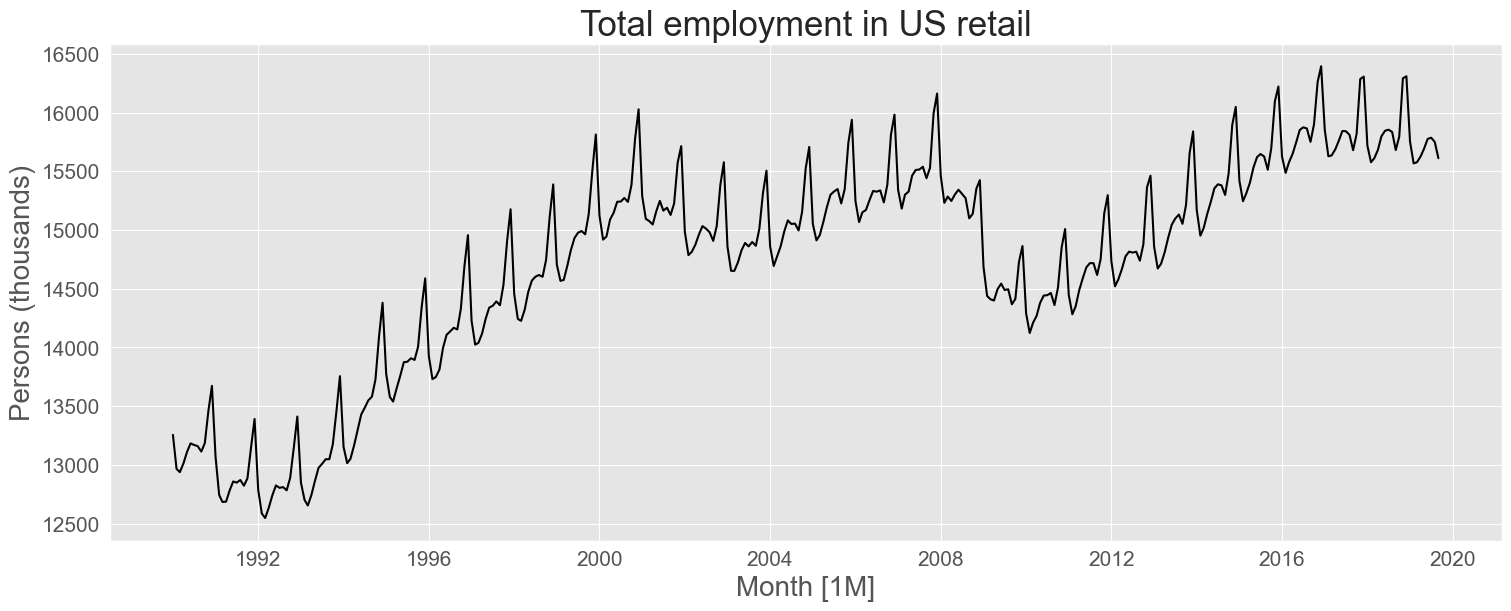

In [4]:
us_employment = pd.read_csv("us_employment.csv", parse_dates=["ds"])
us_retail_employment = us_employment.loc[lambda x:
    (x["unique_id"] == "Retail Trade") & (x["ds"] >= "1990")
]

plot_series(us_retail_employment,
    xlabel="Month [1M]", ylabel="Persons (thousands)",
    title="Total employment in US retail")

In [5]:
stl = STL(us_retail_employment["y"], period=12)
res = stl.fit()

dcmp = pd.DataFrame({
    "ds": us_retail_employment["ds"],
    "data": us_retail_employment["y"],
    "trend": res.trend,
    "seasonal": res.seasonal,
    "remainder": res.resid,
}).reset_index(drop=True)

dcmp.head()

,ds,data,trend,seasonal,remainder
0,1990-01-01,13255.8,13296.249,-3.700,-36.749
1,1990-02-01,12966.3,13276.085,-288.398,-21.387
2,1990-03-01,12938.2,13255.663,-306.658,-10.805
3,1990-04-01,13012.3,13234.986,-235.775,13.089
4,1990-05-01,13108.3,13214.071,-115.399,9.628


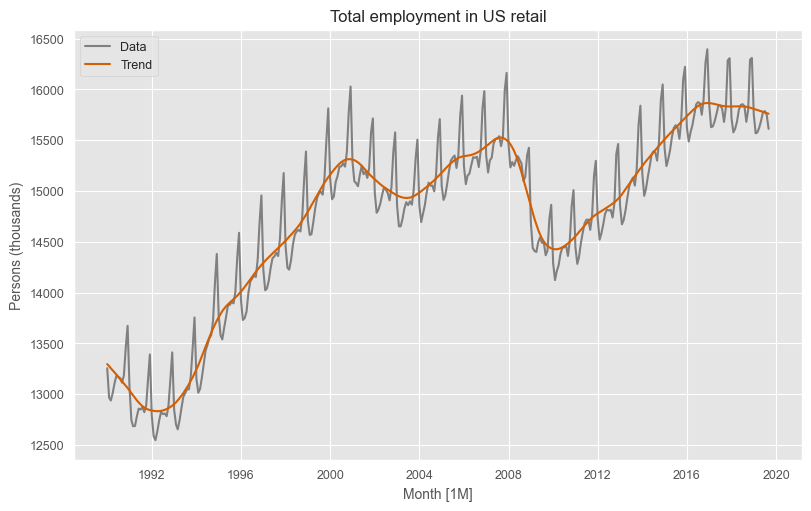

In [6]:
fig, ax = plt.subplots()
sns.lineplot(data=dcmp, x="ds", y="data", color="gray", label="Data")
sns.lineplot(data=dcmp, x="ds", y="trend", color="#D55E00", label="Trend")
ax.set(
    title="Total employment in US retail",
    xlabel="Month [1M]",
    ylabel="Persons (thousands)",
)
plt.show()

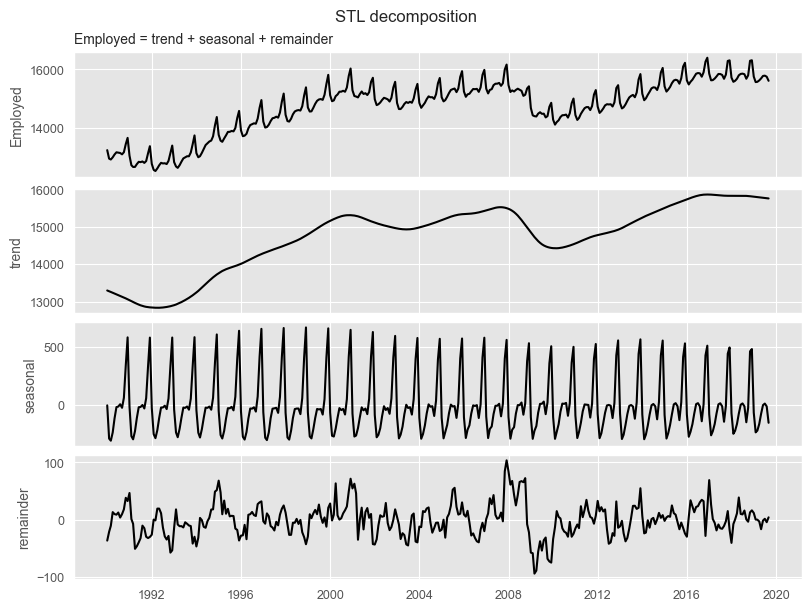

In [7]:
fig, axes = plt.subplots(4, 1, sharex=True, figsize=(8, 6))
sns.lineplot(data=dcmp, x="ds", y="data", ax=axes[0])
sns.lineplot(data=dcmp, x="ds", y="trend", ax=axes[1])
sns.lineplot(data=dcmp, x="ds", y="seasonal", ax=axes[2])
sns.lineplot(data=dcmp, x="ds", y="remainder", ax=axes[3])
axes[0].set_title("Employed = trend + seasonal + remainder",
    size="medium", loc="left")
axes[0].set(ylabel="Employed")
axes[3].set(xlabel="")
fig.suptitle("STL decomposition")
plt.show()

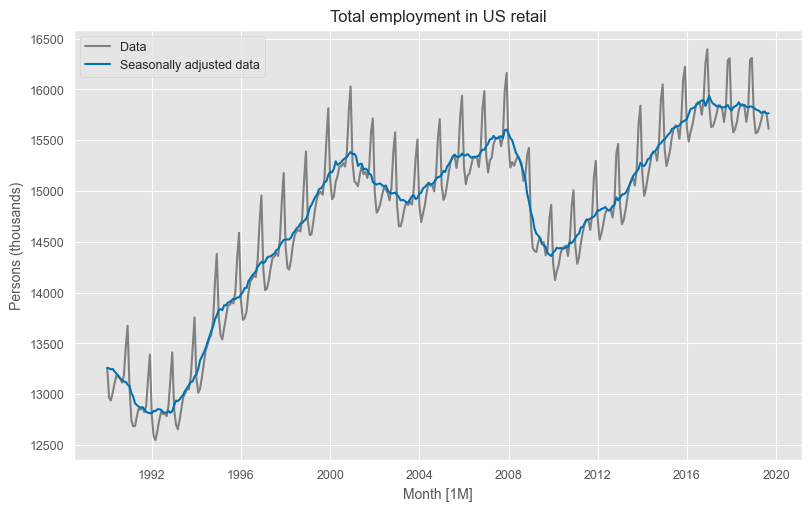

In [8]:
df = dcmp.assign(adj=lambda x: x["data"] - x["seasonal"])

fig, ax = plt.subplots()
sns.lineplot(data=df, x="ds", y="data",
    color="gray", label="Data")
sns.lineplot(data=df, x="ds", y="adj",
    color="#0072B2", label="Seasonally adjusted data")
ax.set(
    title="Total employment in US retail",
    xlabel="Month [1M]",
    ylabel="Persons (thousands)",
)
plt.show()

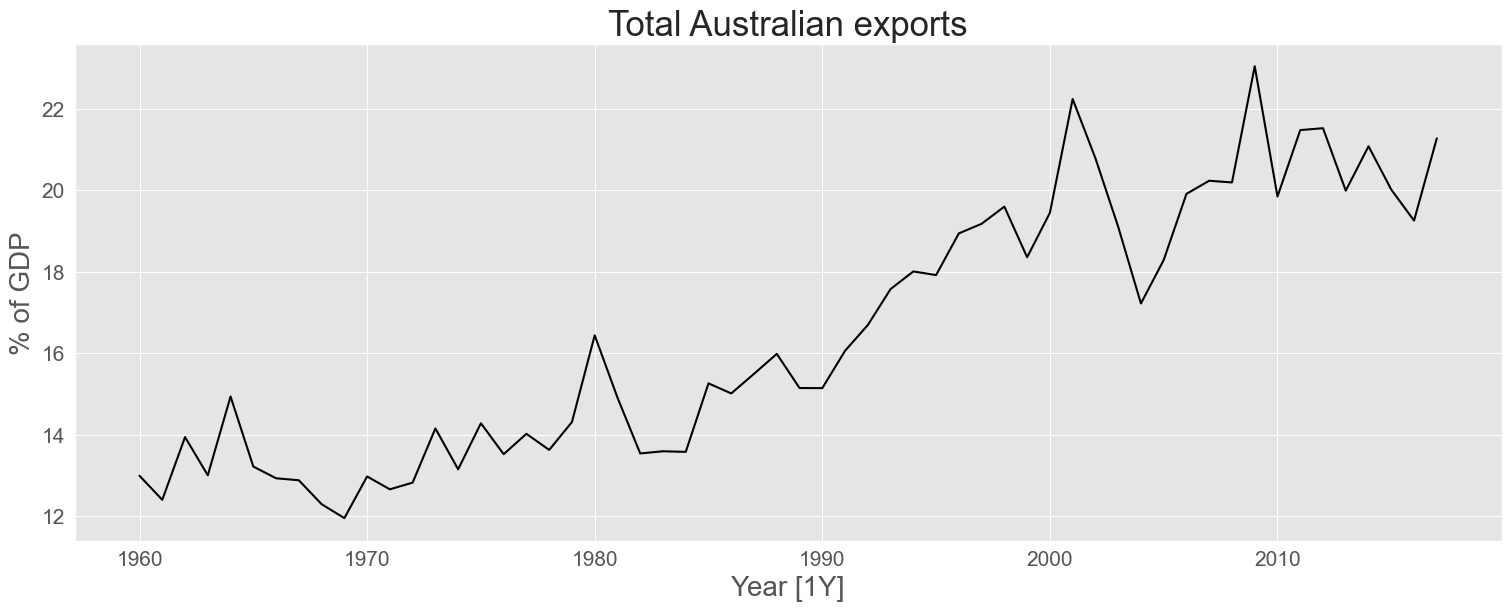

In [9]:
global_economy = pd.read_csv("global_economy.csv")
df = global_economy.loc[lambda x: x["unique_id"] == "Australia"]

plot_series(df, target_col="Exports",
    xlabel="Year [1Y]", ylabel="% of GDP",
    title="Total Australian exports")

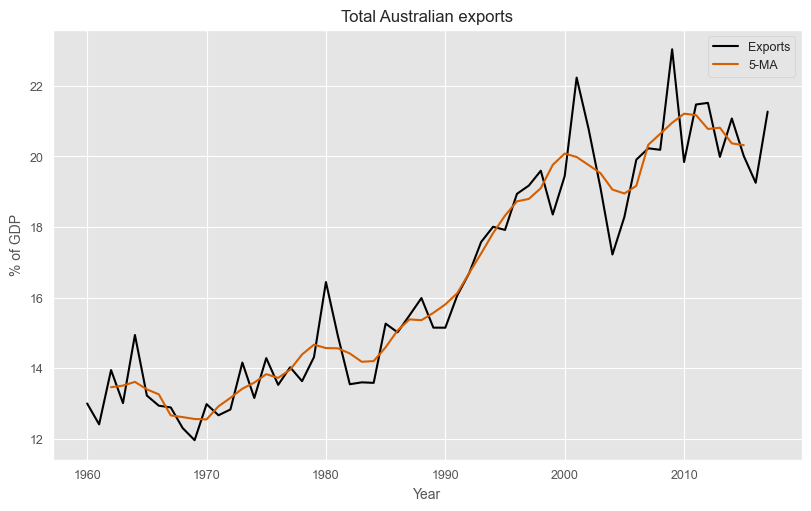

In [10]:
aus_exports = (
    global_economy
    .loc[lambda x: x["unique_id"] == "Australia"]
    .assign(MA_5=lambda x: x["Exports"].rolling(5, center=True).mean())
)


fig, ax = plt.subplots()
sns.lineplot(data=aus_exports, x="ds", y="Exports",
    color="black", label="Exports")
sns.lineplot(data=aus_exports, x="ds", y="MA_5",
    color="#D55E00", label="5-MA")
ax.set(
    title="Total Australian exports",
    xlabel="Year",
    ylabel="% of GDP",
)
plt.show()

In [12]:
aus_production = pd.read_csv("aus_production.csv",
    parse_dates=["ds"])
beer = (
    aus_production[["ds", "Beer"]]
    .loc[lambda x: x["ds"] >= "1992"]
    .reset_index(drop=True)
)
beer["4-MA"] = beer["Beer"].rolling(4, center=True).mean().shift(-1)
beer["2x4-MA"] = beer["4-MA"].rolling(2, center=True).mean()
beer

,ds,Beer,4-MA,2x4-MA
0,1992-01-01,443,NaN,NaN
1,1992-04-01,410,451.25,NaN
2,1992-07-01,420,448.75,450.000
3,1992-10-01,532,451.50,450.125
4,1993-01-01,433,449.00,450.250
...,...,...,...,...
69,2009-04-01,398,430.00,430.000
70,2009-07-01,419,429.75,429.875
71,2009-10-01,488,423.75,426.750
72,2010-01-01,414,NaN,NaN
